### Notebook 2 : Polynomial regression single feature

##### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Load the data set

In [3]:
df = pd.read_csv('capstone.csv')

##### Extract inputs and targets

In [4]:

X = df['Attendance'].values.reshape(-1, 1)
y = df['CapstoneScore'].values

##### Scale X values

In [5]:
X_mean = np.mean(X)
X_std = np.std(X)
X_scaled = (X - X_mean) / X_std

##### Confirm the shapes

In [6]:
print(f"X_scaled shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")

X_scaled shape: (150, 1)
y shape: (150,)


##### Create Polynomial Features

* Takes a (m, 1) input array X and returns a (m, degree+1) feature matrix with columns [1, x, x^2, ..., x^degree]

In [7]:
def create_polynomial_features(X, degree):

    m = X.shape[0]
    X_poly = np.ones((m, degree + 1))  # First column = 1 for β₀ (intercept)
    for d in range(1, degree + 1):
        X_poly[:, d] = X[:, 0] ** d
    return X_poly


* Testing with dummy values

In [8]:
X_poly_2 = create_polynomial_features(X_scaled, degree=2)
print(X_poly_2[:5])

[[ 1.          0.1817678   0.03303953]
 [ 1.         -0.09105992  0.00829191]
 [ 1.          1.65151709  2.72750871]
 [ 1.         -0.29348048  0.08613079]
 [ 1.          0.4721973   0.22297029]]


##### Implement fit polynomial

* Fits a polynomial regression model using gradient descent. Returns the learned beta coefficients and cost history.

In [9]:
def fit_polynomial(X_poly, y, learning_rate=0.1, num_iterations=1000):

    m, n = X_poly.shape
    beta = np.zeros(n)
    cost_history = []

    for i in range(num_iterations):
        predictions = X_poly @ beta  # (m, n) @ (n,) → (m,)
        errors = predictions - y
        cost = (1 / (2 * m)) * np.sum(errors ** 2)
        cost_history.append(cost)

        gradients = (1 / m) * (X_poly.T @ errors)
        beta -= learning_rate * gradients

    return beta, cost_history


##### Train and Visualize Polynomial Regression (Degree 1)

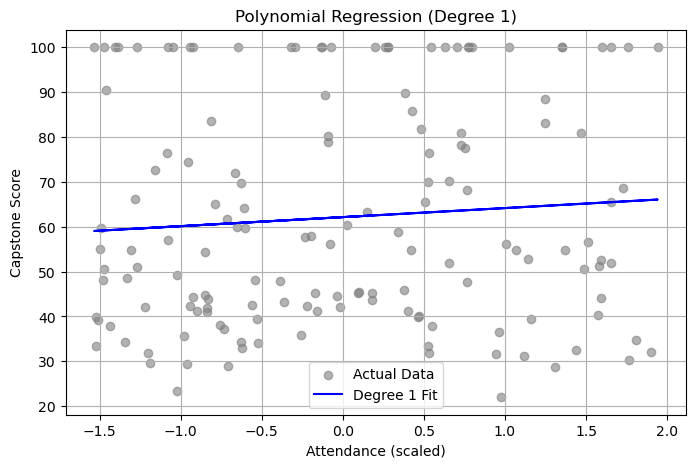

Beta (degree 1): [62.13733333  2.01449287]


In [10]:
# DEGREE 1
X_poly_1 = create_polynomial_features(X_scaled, degree=1)
beta_1, cost_history_1 = fit_polynomial(X_poly_1, y, learning_rate=0.1)

# Predict
y_pred_1 = X_poly_1 @ beta_1

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_scaled, y, label='Actual Data', color='gray', alpha=0.6)
plt.plot(X_scaled, y_pred_1, label='Degree 1 Fit', color='blue')
plt.xlabel('Attendance (scaled)')
plt.ylabel('Capstone Score')
plt.title('Polynomial Regression (Degree 1)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Beta (degree 1): {beta_1}")


##### Train and Visualize Polynomial Regression (Degree 2)

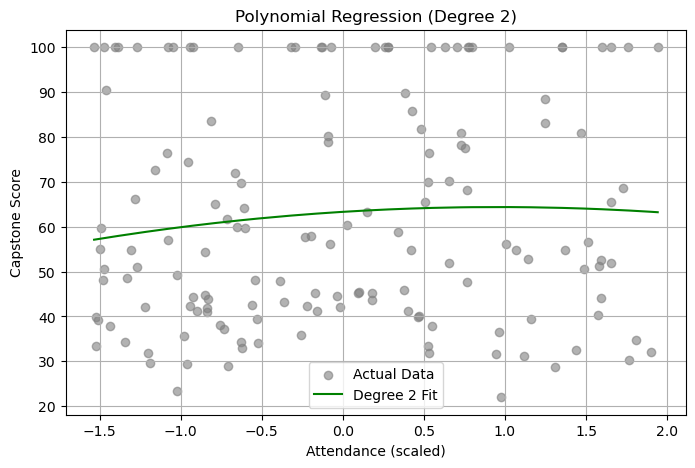

Beta (degree 2): [63.31423524  2.24168208 -1.1769019 ]


In [11]:
# DEGREE 2
X_poly_2 = create_polynomial_features(X_scaled, degree=2)
beta_2, cost_history_2 = fit_polynomial(X_poly_2, y, learning_rate=0.1)

# Predict
y_pred_2 = X_poly_2 @ beta_2

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_scaled, y, label='Actual Data', color='gray', alpha=0.6)

# Sort X and y_pred to get a smooth curve
sorted_indices = np.argsort(X_scaled[:, 0])
plt.plot(X_scaled[sorted_indices], y_pred_2[sorted_indices], label='Degree 2 Fit', color='green')

plt.xlabel('Attendance (scaled)')
plt.ylabel('Capstone Score')
plt.title('Polynomial Regression (Degree 2)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Beta (degree 2): {beta_2}")


##### Train and Visualize Polynomial Regression (Degree 3)

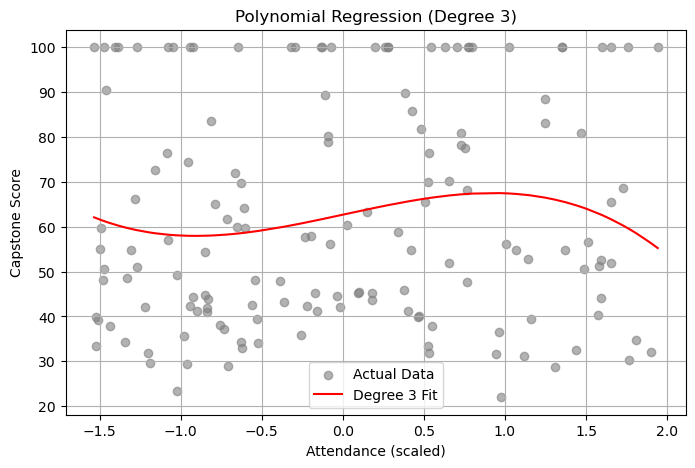

Beta (degree 3): [ 6.26815501e+01  7.83127649e+00  5.86817439e-02 -3.12317856e+00]


In [12]:
# DEGREE 3
X_poly_3 = create_polynomial_features(X_scaled, degree=3)
beta_3, cost_history_3 = fit_polynomial(X_poly_3, y, learning_rate=0.1)

# Predict
y_pred_3 = X_poly_3 @ beta_3

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_scaled, y, label='Actual Data', color='gray', alpha=0.6)

# Sort X and predictions for smoother curve
sorted_indices = np.argsort(X_scaled[:, 0])
plt.plot(X_scaled[sorted_indices], y_pred_3[sorted_indices], label='Degree 3 Fit', color='red')

plt.xlabel('Attendance (scaled)')
plt.ylabel('Capstone Score')
plt.title('Polynomial Regression (Degree 3)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Beta (degree 3): {beta_3}")


##### Compute R2 for Each Degree

In [16]:
def r2_score(y_true, y_pred):
    y_mean = y_true.mean()
    ss_res = ((y_true - y_pred) ** 2).sum()    # Residual sum of squares
    ss_tot = ((y_true - y_mean) ** 2).sum()    # Total sum of squares
    r2 = 1 - (ss_res / ss_tot)
    return r2

r2_deg1_manual = r2_score(y, y_pred_1)
r2_deg2_manual = r2_score(y, y_pred_2)
r2_deg3_manual = r2_score(y, y_pred_3)

print(f"Manual R² Score (Degree 1): {r2_deg1_manual:.4f}")
print(f"Manual R² Score (Degree 2): {r2_deg2_manual:.4f}")
print(f"Manual R² Score (Degree 3): {r2_deg3_manual:.4f}")


Manual R² Score (Degree 1): 0.0067
Manual R² Score (Degree 2): 0.0085
Manual R² Score (Degree 3): 0.0190
